# Steam Hardware Survey Analysis

This notebook contains all the Python analysis scripts used in my MA2511 report.


| **Student name** | Piotr Weychan |
| :--------------- | :------------------ |
|**Student ID**    | `-` |
|**Project title** | Exploring Trends in PC Hardware Evolution Using Linear Algebra |

In [1]:
# install requirements
%pip install pandas scipy requests certifi kagglehub dotenv matplotlib

# load .env
import dotenv

dotenv.load_dotenv()

# import them
import pandas as pd
import numpy as np
import datetime as dt
import math as maths
import kagglehub

  Using cached pandas-3.0.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached numpy-2.4.4-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached charset_normalizer-3.4.7-cp314-cp314-macosx_10_15_universal2.whl.metadata (40 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached kagglesdk-0.1.19-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached protobuf-7.34.1-cp310-abi3-

/Users/squirrel/git/uni/SteamHWSAnalysis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Utility functions!

# convert size to megabytes
def as_mb(size: str) -> float:
  # deal with ranges (very basically)
  size = size.split(" to ")[-1]

  # quick and dirty system for dealing with non-standard values
  if size.startswith("More than "):
    val, unit = size.split(" ")[-2:]
    val = float(val) * 1.5
  elif size.startswith("Less than "):
    val, unit = size.split(" ")[-2:]
    val = float(val) * 0.5
  elif size.endswith(" and higher"):
    val, unit = size.split(" ")[:2]
    val = float(val) * 1.5
  else:
    unit = size[-2:].upper()
    val = float(size[:-3])

  if unit == "MB":
    return val
  elif unit == "KB":
    return val / (1 << 10)
  elif unit == "GB":
    return val * (1 << 10)
  elif unit == "TB":
    return val * (1 << 20)
  else:
    return float("nan")

# gets weighted average on the field
def weighted_avg_on(df: pd.DataFrame, fieldName: str = "name") -> pd.Series:

  tmp = df.copy()

  weights = tmp["percentage"]
  weights /= tmp.groupby("date")["percentage"].transform("sum")

  tmp = tmp.assign(weighted_value=tmp[fieldName] * weights)

  return tmp.groupby("date")["weighted_value"].sum()

  # # Normalise share values (removal of Other option causes values not to add up to 1)
  # df.insert(5, "percentage_normalised", (
  #   df["percentage"] / df.groupby("date")["percentage"].transform("sum")
  # ))

  # # Get weighted averages and return them as a series
  # return (
  #   df.groupby("date")
  #     .apply(lambda x: (x[fieldName] * x["percentage_normalised"]).sum())
  # )

In [3]:
# Fetch the source data and import it into a DataFrame

# read steam hw survey data from remote source
# locked at March 2026 results
raw_data = pd.read_csv("https://github.com/jdegene/steamHWsurvey/raw/68066407f287b497d08c3466ea4e7f5d073efc8f/shs.csv")

# also download gpu performance dataset

# Load the latest version
gpu_benches = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "alanjo/gpu-benchmarks",
  "GPU_benchmarks_v7.csv",
)

# Streamline data by dropping change column
raw_data = raw_data.drop(["change"], axis=1)

# Fix up data types for dates
raw_data["date"] = raw_data["date"].map(dt.datetime.fromisoformat)
# Filter data to only include last 8 years (10 has data errors)
raw_data = raw_data[raw_data["date"] > dt.datetime(2018, 3, 1)]

# Remove ALL other values from name fields
raw_data = raw_data[raw_data["name"] != "Other"]
raw_data = raw_data[raw_data["name"] != "Unspecified"]

# raw_data[raw_data["category"] == "Primary Display Resolution"]["name"].unique()
# raw_data["category"].unique()

In [4]:
# Transform data into a matrix-compatible form

# ======== VRAM ========
vram = raw_data[raw_data["category"] == "VRAM"].copy()

# convert string formatted MB value into raw byte count
vram.insert(
  loc=2, column="mbytes", value=(
    vram["name"].apply(as_mb)
  )
)
# Check if there are any null entries
# vram[vram["bytes"].isna()]

avg_vram = weighted_avg_on(vram, "mbytes")

# ======== RAM ========
ram = raw_data[raw_data["category"] == "System RAM"].copy()

# convert string formatted MB value into raw byte count
ram.insert(
  loc=2, column="mbytes", value=(
    ram["name"].apply(as_mb)
  )
)

avg_ram = weighted_avg_on(ram, "mbytes")


# ======== CPU Cores ========
cores = raw_data[raw_data["category"] == "Physical CPUs"]

cores.insert(
  loc=2, column="cores", value=(
    cores["name"].apply(lambda x: int(x.split(" ")[0]))
  )
)

avg_cores = weighted_avg_on(cores, "cores")

# ======== Resolution ========
resolution = raw_data[raw_data["category"] == "Primary Display Resolution"]

resolution.insert(
  loc=2, column="mpixels", value=(
    resolution["name"].apply(lambda x: maths.prod([int(y) for y in x.split(" x ")])) / 1e6
  )
)

avg_resolution = weighted_avg_on(resolution, "mpixels")


# ======== GPU Benchmarks ========

gpu = raw_data[raw_data["category"] == "Video Card Description"].copy()

# get names (cleaned consistently)
shs_gpu_names = (
    gpu["name"]
    .map(lambda x: str(x).replace("NVIDIA ", "").replace("AMD ", "").replace("ATI ", ""))
    .unique()
)

bench_gpu_names = gpu_benches["gpuName"]

matched = set(shs_gpu_names) & set(bench_gpu_names)

# add clean column
gpu.insert(
  loc=2,
  column="gpu_clean",
  value=(
    gpu["name"].astype(str)
    .str.replace("NVIDIA ", "", regex=False)
    .str.replace("AMD ", "", regex=False)
    .str.replace("ATI ", "", regex=False)
  )
)

gpu = gpu[gpu["gpu_clean"].isin(matched)]

# merge benchmarks
gpu = gpu.merge(
  gpu_benches[["gpuName", "G3Dmark"]],
  left_on="gpu_clean",
  right_on="gpuName",
  how="left",
).drop(columns=["gpuName", "gpu_clean"])

# gpu.groupby("date")["G3Dmark"].apply(lambda x: x.isna().any())

avg_gpu_bench = weighted_avg_on(gpu, "G3Dmark")


In [5]:
# Build the matrix


# starting dataframe
matrix_df = pd.concat(
  [
    avg_cores,
    avg_ram,
    avg_gpu_bench,
    avg_vram,
    avg_resolution
  ],
  axis=1,
)

matrix_df.columns = ["Cores", "RAM", "GPU Benchmark", "VRAM", "Resolution"]

# convert to 'matrix'
X = matrix_df.values

# normalise data by means
X_std = ((matrix_df - matrix_df.mean()) / matrix_df.std()).values

# display data outline
matrix_df.head(10)

,Cores,RAM,GPU Benchmark,VRAM,Resolution
date,,,,,
2018-04-01,3.449045,11009.610461,6555.803894,3067.422177,1.944882
2018-05-01,3.453400,11006.922084,6613.638047,3087.101661,1.948057
2018-06-01,3.465693,11004.334567,6677.844796,3122.751063,1.950703
2018-07-01,3.421442,11068.969391,6628.984995,3129.598875,1.961522
2018-08-01,3.545155,11181.667900,6903.591495,3234.487570,1.967602
2018-09-01,3.568514,10643.210879,6945.871249,3702.126009,1.979078
2018-10-01,3.535854,10629.914783,6988.561553,3681.858100,1.992960
2018-11-01,3.620400,10683.436344,7092.311582,3822.382307,1.985776
2018-12-01,3.622725,10700.902400,7193.654845,3816.079302,1.982551


## Linear Algebra + Analytics
This section focuses on working on the data to identify patterns and other linear algebra stuff.

In [6]:
from scipy.linalg import eigh

# build covariance matrix
C = np.cov(X_std, rowvar=False)

# compute eigenvalues + eigenvectors from covariance matrix
eigvals, eigvecs = eigh(C)

# verify the diagonalisation performed in eigh(C)
P = eigvecs
D = np.diag(eigvals)
P_inv = np.linalg.inv(P)

# verify that C = PDP^{-1}
np.allclose(C, P @ D @ P_inv)

True

In [7]:
# sort the eigen{values,vectors} by eigenvalues
idx = np.argsort(eigvals)[::-1]

eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# explains which eigenvector explains what proportion of variation
variance_explanation = eigvals / eigvals.sum()

print(variance_explanation)

# display PC1 coefficients
print(variance_explanation[0], eigvecs[:, 0])
print(variance_explanation[1], eigvecs[:, 1])

# project data onto PCA coeffs1
X_pca = X_std @ eigvecs[:, :2]

eigvecs[:, 0].std()

[9.82685976e-01 1.16291078e-02 4.72203429e-03 7.71829181e-04
 1.91052772e-04]
0.9826859759337265 [-0.45001405 -0.44748699 -0.44156704 -0.44688002 -0.45006615]
0.01162910781873706 [ 0.23315511  0.45437336 -0.81870688 -0.11730525  0.23482349]


np.float64(0.003099956837040467)

## Graphs

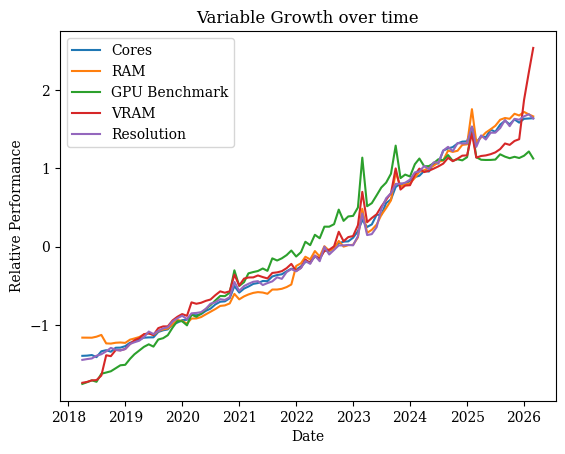

In [8]:
# generate some graphs of the data
from dateutil.relativedelta import relativedelta
import matplotlib as mpl
from matplotlib import pyplot

mpl.rcParams["font.family"] = "serif"

std_df = pd.DataFrame(
  X_std,
  columns = ["Cores", "RAM", "GPU Benchmark", "VRAM", "Resolution"]
)

std_df.index = [ dt.datetime(2018, 4, 1) + relativedelta(months=i) for i in range(96) ]

fig, ax = pyplot.subplots()
ax.plot(std_df)
ax.set_xlabel("Date")
ax.set_ylabel("Relative Performance")
ax.set_title("Variable Growth over time")
ax.legend(["Cores", "RAM", "GPU Benchmark", "VRAM", "Resolution"])

pyplot.savefig("var_growth.pdf")  

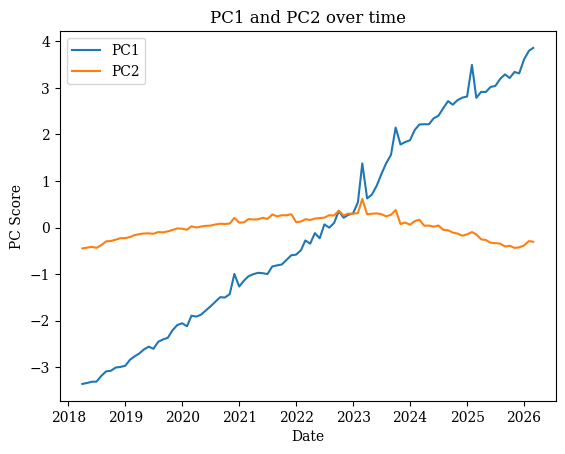

In [9]:
# PC1 shown going down, going up makes more sense
X_pca[:, 0] *= -1 if X_pca[0,0] > X_pca[95,0] else 1
# PC2 going up makes more sense
X_pca[:, 1] *= -1 if X_pca[0,1] > X_pca[95//2,1] else 1

pca_df = pd.DataFrame(
  X_pca,
  columns = ["PC1", "PC2"]
)

pca_df.index = [ dt.datetime(2018, 4, 1) + relativedelta(months=i) for i in range(96) ]

fig, ax = pyplot.subplots()
ax.plot(pca_df)
ax.set_xlabel("Date")
ax.set_ylabel("PC Score")
ax.set_title("PC1 and PC2 over time")
ax.legend(["PC1", "PC2"])

pyplot.savefig("pc_scores_time.pdf")

In [10]:
# generate session information
import sys

print(f"Python {sys.version}\n")
with open("requirements.txt", "r") as f:
  print(f.read())

Python 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]

appnope==0.1.4
asttokens==3.0.1
certifi==2026.2.25
charset-normalizer==3.4.7
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
dotenv==0.9.9
executing==2.2.1
fonttools==4.62.1
idna==3.12
ipykernel==7.2.0
ipython==9.12.0
ipython_pygments_lexers==1.1.1
jedi==0.19.2
jupyter_client==8.8.0
jupyter_core==5.9.1
kagglehub==1.0.0
kagglesdk==0.1.19
kiwisolver==1.5.0
matplotlib==3.10.8
matplotlib-inline==0.2.1
nest-asyncio==1.6.0
numpy==2.4.4
packaging==26.1
pandas==3.0.2
parso==0.8.6
pexpect==4.9.0
pillow==12.2.0
platformdirs==4.9.6
prompt_toolkit==3.0.52
protobuf==7.34.1
psutil==7.2.2
ptyprocess==0.7.0
pure_eval==0.2.3
Pygments==2.20.0
pyparsing==3.3.2
python-dateutil==2.9.0.post0
python-dotenv==1.2.2
PyYAML==6.0.3
pyzmq==27.1.0
requests==2.33.1
scipy==1.17.1
six==1.17.0
stack-data==0.6.3
tornado==6.5.5
tqdm==4.67.3
traitlets==5.14.3
urllib3==2.6.3
wcwidth==0.6.0

